# 🦴 PaleoWave — PBDB Data Harvester
**Pulls ichthyosaur and broader Triassic marine fossil occurrences from the Paleobiology Database API.**

Outputs:
- `data/pbdb/pbdb_occurrences_raw.csv` — full raw API response
- `data/pbdb/pbdb_occurrences_clean.csv` — filtered, validated, field-ready
- `data/pbdb/pbdb_occurrences.geojson` — spatial file for QGIS / geopandas

PBDB API docs: https://paleobiodb.org/data1.2/

## 1. Imports & Setup

In [1]:
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point
from pathlib import Path
import json
import time

# Output directories
DATA_DIR = Path('../data/pbdb')
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f'Output directory: {DATA_DIR.resolve()}')

Output directory: C:\Users\brook\Documents\Project-PaleoWave\data\pbdb


## 2. Query Configuration
Adjust these parameters to broaden or narrow the search.

In [2]:
# ── Search parameters ──────────────────────────────────────────────────────

# Primary target — ichthyosaurs
TAXA = [
    'Ichthyosauria',      # Full order — all ichthyosaurs
    'Shonisaurus',        # Nevada's own genus
    'Cymbospondylus',     # Common in Nevada Triassic
]

# Time interval — Triassic (when Nevada was a shallow sea)
TIME_INTERVAL = 'Triassic'

# Geographic bounding box — Nevada + generous buffer into neighboring states
# Format: lng_min, lat_min, lng_max, lat_max
BBOX = '-120.5,35.0,-114.0,42.5'

# PBDB API base URL
BASE_URL = 'https://paleobiodb.org/data1.2/occs/list.json'

# Fields to request from API
SHOW_FIELDS = 'coords,classext,ident,geo,strat,time,ref'

print('Query config set.')
print(f'Taxa targets: {TAXA}')
print(f'Time interval: {TIME_INTERVAL}')
print(f'Bounding box: {BBOX}')

Query config set.
Taxa targets: ['Ichthyosauria', 'Shonisaurus', 'Cymbospondylus']
Time interval: Triassic
Bounding box: -120.5,35.0,-114.0,42.5


## 3. Fetch Occurrences from PBDB

In [3]:
def fetch_pbdb(taxon, interval, bbox, show):
    """Fetch occurrences for a single taxon from the PBDB API."""
    params = {
        'base_name': taxon,
        'interval': interval,
        'lngmin': bbox.split(',')[0],
        'latmin': bbox.split(',')[1],
        'lngmax': bbox.split(',')[2],
        'latmax': bbox.split(',')[3],
        'show': show,
        'limit': 5000,
    }
    print(f'  Fetching: {taxon}...')
    resp = requests.get(BASE_URL, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    records = data.get('records', [])
    print(f'  → {len(records)} occurrences returned')
    return records


# Fetch all taxa
all_records = []
for taxon in TAXA:
    records = fetch_pbdb(taxon, TIME_INTERVAL, BBOX, SHOW_FIELDS)
    for r in records:
        r['query_taxon'] = taxon  # track which query returned this record
    all_records.extend(records)
    time.sleep(0.5)  # be polite to the API

print(f'\nTotal raw records: {len(all_records)}')

  Fetching: Ichthyosauria...
  → 30 occurrences returned
  Fetching: Shonisaurus...
  → 3 occurrences returned
  Fetching: Cymbospondylus...
  → 10 occurrences returned

Total raw records: 43


## 4. Build DataFrame & Save Raw

In [4]:
df_raw = pd.DataFrame(all_records)
print(f'Raw shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')

# Save raw
raw_path = DATA_DIR / 'pbdb_occurrences_raw.csv'
df_raw.to_csv(raw_path, index=False)
print(f'\nRaw data saved to: {raw_path}')

df_raw.head(3)

Raw shape: (43, 39)
Columns: ['oid', 'cid', 'idn', 'tna', 'rnk', 'tid', 'oei', 'eag', 'lag', 'rid', 'lng', 'lat', 'phl', 'phn', 'cll', 'cln', 'odl', 'odn', 'fml', 'fmn', 'gnl', 'gnn', 'idg', 'rsg', 'ids', 'rss', 'env', 'sfm', 'cxi', 'ref', 'query_taxon', 'tec', 'gcm', 'smb', 'oli', 'sgr', 'tdf', 'iid', 'idr']

Raw data saved to: ..\data\pbdb\pbdb_occurrences_raw.csv


,oid,cid,idn,tna,rnk,tid,oei,eag,lag,rid,...,ref,query_taxon,tec,gcm,smb,oli,sgr,tdf,iid,idr
0,occ:361674,col:34267,Omphalosaurus nevadanus n. gen. n. sp.,Omphalosaurus nevadanus,3,txn:54114,Middle Triassic,246.7,237.0,ref:9007,...,J. C. Merriam. 1906. Preliminary note on a new...,Ichthyosauria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,occ:467069,col:34267,Cymbospondylus sp.,Cymbospondylus,5,txn:36550,Middle Triassic,246.7,237.0,ref:9007,...,J. C. Merriam. 1906. Preliminary note on a new...,Ichthyosauria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,occ:467070,col:34267,NaN,Cymbospondylus petrinus,3,txn:170850,Middle Triassic,246.7,237.0,ref:9007,...,J. C. Merriam. 1906. Preliminary note on a new...,Ichthyosauria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Clean & Validate

In [5]:
df = df_raw.copy()

# ── Rename key columns for clarity ────────────────────────────────────────
rename_map = {
    'oid': 'occurrence_id',
    'tna': 'taxon_name',
    'rnk': 'taxon_rank',
    'lng': 'longitude',
    'lat': 'latitude',
    'fml': 'family',
    'odl': 'order',
    'cll': 'class',
    'phl': 'phylum',
    'eag': 'early_age_ma',
    'lag': 'late_age_ma',
    'sfm': 'formation',
    'sgr': 'stratgroup',
    'smb': 'member',
    'cc2': 'country_code',
    'stp': 'state',
    'cny': 'county',
    'prc': 'coord_precision',
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# ── Drop records without coordinates ──────────────────────────────────────
before = len(df)
df = df.dropna(subset=['latitude', 'longitude'])
print(f'Dropped {before - len(df)} records with no coordinates')

# ── Convert coordinate columns to float ───────────────────────────────────
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df = df.dropna(subset=['latitude', 'longitude'])

# ── Drop duplicates by occurrence_id ──────────────────────────────────────
if 'occurrence_id' in df.columns:
    before = len(df)
    df = df.drop_duplicates(subset='occurrence_id')
    print(f'Dropped {before - len(df)} duplicate occurrence IDs')

# ── Filter to valid lat/lng ranges ────────────────────────────────────────
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]

print(f'\nClean record count: {len(df)}')
df.head(3)

Dropped 0 records with no coordinates
Dropped 13 duplicate occurrence IDs

Clean record count: 30


,occurrence_id,cid,idn,taxon_name,taxon_rank,tid,oei,early_age_ma,late_age_ma,rid,...,ref,query_taxon,tec,gcm,member,oli,stratgroup,tdf,iid,idr
0,occ:361674,col:34267,Omphalosaurus nevadanus n. gen. n. sp.,Omphalosaurus nevadanus,3,txn:54114,Middle Triassic,246.7,237.0,ref:9007,...,J. C. Merriam. 1906. Preliminary note on a new...,Ichthyosauria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,occ:467069,col:34267,Cymbospondylus sp.,Cymbospondylus,5,txn:36550,Middle Triassic,246.7,237.0,ref:9007,...,J. C. Merriam. 1906. Preliminary note on a new...,Ichthyosauria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,occ:467070,col:34267,NaN,Cymbospondylus petrinus,3,txn:170850,Middle Triassic,246.7,237.0,ref:9007,...,J. C. Merriam. 1906. Preliminary note on a new...,Ichthyosauria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Add Derived Fields

In [6]:
# Mid-point age estimate
if 'early_age_ma' in df.columns and 'late_age_ma' in df.columns:
    df['early_age_ma'] = pd.to_numeric(df['early_age_ma'], errors='coerce')
    df['late_age_ma'] = pd.to_numeric(df['late_age_ma'], errors='coerce')
    df['mid_age_ma'] = (df['early_age_ma'] + df['late_age_ma']) / 2

# Nevada flag
if 'state' in df.columns:
    df['in_nevada'] = df['state'].str.upper().str.strip() == 'NV'
elif 'country_code' in df.columns:
    # Rough bounding box for Nevada
    df['in_nevada'] = (
        df['latitude'].between(35.0, 42.0) &
        df['longitude'].between(-120.0, -114.0)
    )

nevada_count = df['in_nevada'].sum() if 'in_nevada' in df.columns else 'unknown'
print(f'Records in Nevada: {nevada_count}')
print(f'Total clean records: {len(df)}')

Records in Nevada: unknown
Total clean records: 30


## 7. Save Clean CSV & GeoJSON

In [7]:
# Save clean CSV
clean_path = DATA_DIR / 'pbdb_occurrences_clean.csv'
df.to_csv(clean_path, index=False)
print(f'Clean CSV saved: {clean_path}')

# Build GeoDataFrame
geometry = [Point(row['longitude'], row['latitude']) for _, row in df.iterrows()]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

# Save GeoJSON
geojson_path = DATA_DIR / 'pbdb_occurrences.geojson'
gdf.to_file(geojson_path, driver='GeoJSON')
print(f'GeoJSON saved:   {geojson_path}')

print(f'\nTotal records exported: {len(gdf)}')

Clean CSV saved: ..\data\pbdb\pbdb_occurrences_clean.csv
GeoJSON saved:   ..\data\pbdb\pbdb_occurrences.geojson

Total records exported: 30


## 8. Quick Summary Stats

In [8]:
print('=== PBDB Harvest Summary ===')
print(f'Total occurrences:      {len(df)}')

if 'in_nevada' in df.columns:
    print(f'Nevada occurrences:     {df["in_nevada"].sum()}')

if 'taxon_name' in df.columns:
    print(f'\nTop taxa:')
    print(df['taxon_name'].value_counts().head(10).to_string())

if 'formation' in df.columns:
    print(f'\nTop formations:')
    print(df['formation'].value_counts().head(10).to_string())

if 'state' in df.columns:
    print(f'\nBy state:')
    print(df['state'].value_counts().head(10).to_string())

=== PBDB Harvest Summary ===
Total occurrences:      30

Top taxa:
taxon_name
Cymbospondylus petrinus    3
Ichthyosauria              3
Ichthyosaurus              3
Mixosaurus                 3
Shonisaurus                2
Omphalosaurus nevadanus    1
Cymbospondylus             1
Cymbospondylus natans      1
Phalarodon fraasi          1
Cymbospondylus piscosus    1

Top formations:
formation
Prida     9
Favret    7
Luning    6
Gabbs     1


## 9. Map the Occurrences

C:\Users\brook\AppData\Local\Temp\ipykernel_25792\243015072.py:41: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\brook\AppData\Local\Temp\ipykernel_25792\243015072.py:43: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.savefig(map_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
C:\Users\brook\Documents\Project-PaleoWave\.pixi\envs\default\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


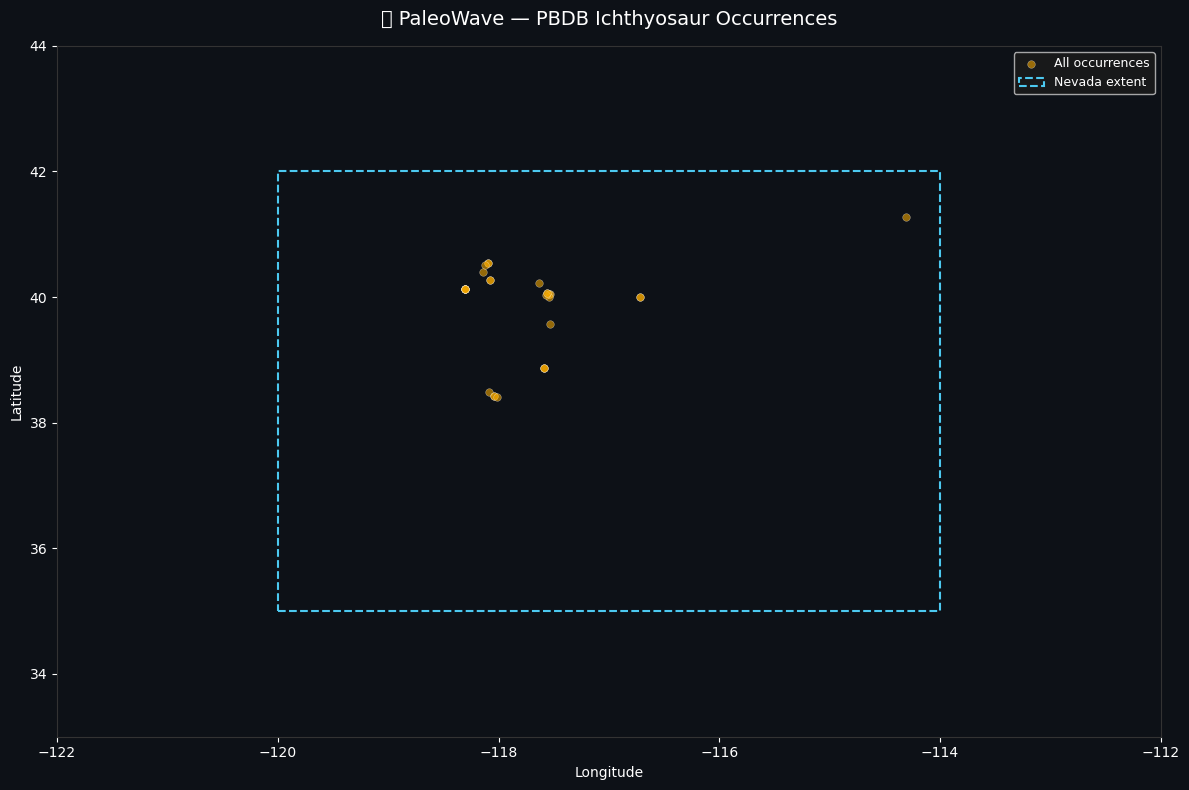

Map saved: ..\data\pbdb\pbdb_occurrence_map.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# All occurrences
ax.scatter(
    df['longitude'], df['latitude'],
    s=30, alpha=0.6, color='#f0a500', linewidths=0.3, edgecolors='white',
    label='All occurrences'
)

# Nevada occurrences highlighted
if 'in_nevada' in df.columns:
    nv = df[df['in_nevada']]
    ax.scatter(
        nv['longitude'], nv['latitude'],
        s=60, alpha=0.9, color='#e63946', linewidths=0.5, edgecolors='white',
        label=f'Nevada ({len(nv)})'
    )

# Nevada bounding box
from matplotlib.patches import Rectangle
nv_box = Rectangle((-120.0, 35.0), 6.0, 7.0,
                   linewidth=1.5, edgecolor='#4cc9f0', facecolor='none',
                   linestyle='--', label='Nevada extent')
ax.add_patch(nv_box)

ax.set_xlim(-122, -112)
ax.set_ylim(33, 44)
ax.set_xlabel('Longitude', color='white')
ax.set_ylabel('Latitude', color='white')
ax.set_title('🦴 PaleoWave — PBDB Ichthyosaur Occurrences', 
             color='white', fontsize=14, pad=15)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')

legend = ax.legend(facecolor='#1c1c1c', labelcolor='white', 
                   framealpha=0.8, fontsize=9)

plt.tight_layout()
map_path = DATA_DIR / 'pbdb_occurrence_map.png'
plt.savefig(map_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Map saved: {map_path}')

## ✅ Done

Outputs written to `data/pbdb/`:
- `pbdb_occurrences_raw.csv` — unmodified API response
- `pbdb_occurrences_clean.csv` — cleaned and validated
- `pbdb_occurrences.geojson` — ready for QGIS or next pipeline step
- `pbdb_occurrence_map.png` — quick visual check

**Next step:** `02_terrain_analysis.ipynb` — LiDAR terrain metric extraction

In [10]:
# Fix Nevada flag using coordinates (state field not in this API response)
df_fix = pd.read_csv('../data/pbdb/pbdb_occurrences_clean.csv')

df_fix['in_nevada'] = (
    df_fix['latitude'].between(35.0, 42.0) &
    df_fix['longitude'].between(-120.0, -114.0)
)

print(f"Nevada records: {df_fix['in_nevada'].sum()}")
print(f"\nNevada occurrences:")
print(df_fix[df_fix['in_nevada']][['taxon_name', 'latitude', 'longitude', 'formation']].to_string())

# Overwrite clean CSV with fixed flag
df_fix.to_csv('../data/pbdb/pbdb_occurrences_clean.csv', index=False)
print("\nSaved with corrected Nevada flag.")

Nevada records: 30

Nevada occurrences:
                     taxon_name   latitude   longitude formation
0       Omphalosaurus nevadanus  40.133331 -118.300003     Prida
1                Cymbospondylus  40.133331 -118.300003     Prida
2       Cymbospondylus petrinus  40.133331 -118.300003     Prida
3         Cymbospondylus natans  40.133331 -118.300003     Prida
4             Phalarodon fraasi  40.133331 -118.300003     Prida
5                 Ichthyosauria  40.133331 -118.300003     Prida
6                 Ichthyosauria  38.487000 -118.083000     Gabbs
7                 Ichthyosaurus  38.431946 -118.045830    Luning
8                 Ichthyosaurus  38.431946 -118.045830    Luning
9                 Ichthyosaurus  38.402000 -118.016998    Luning
10                Ichthyosauria  40.000000 -116.716667       NaN
11      Cymbospondylus piscosus  40.000000 -116.716667       NaN
12      Cymbospondylus petrinus  40.548058 -118.099998       NaN
13       Chonespondylus grandis  40.548058 -118.09